In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import matplotlib.dates as mdates
import datetime


"""
04931 
19880101 
20260817            
371     
48.6883    
9.2235 
Stuttgart-Echterdingen                  
Baden-Württemberg                        
Frei

https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/air_temperature/recent/
stundenwerte_TU_04931_akt.zip  
"""

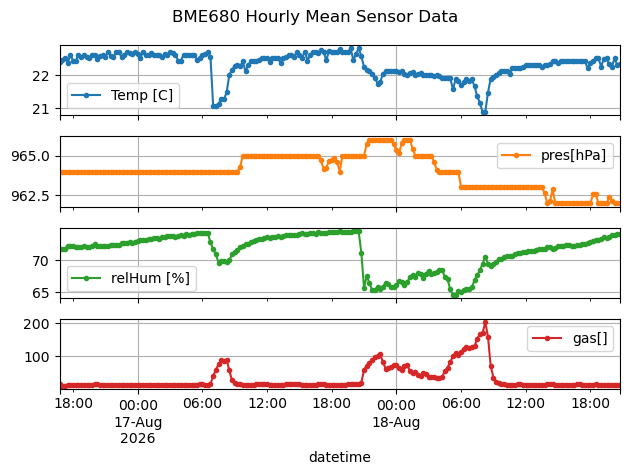

In [35]:
AVG = '15min'

fnames = [
    'sensor_data_2026-08-01_11_12_05.csv',
    'sensor_data_2026-08-01_12_49_16.csv',
    'sensor_data_2026-08-01_13_07_13.csv',
    'sensor_data_2026-08-09_14_57_20.csv',
    'sensor_data_2026-08-10_07_31_15.csv',
    'sensor_data_2026-08-12_16_50_41.csv',
    'sensor_data_2026-08-16_16_45_23.csv',
    'sensor_data_2026-08-17_08_17_41.csv'
]

dfs = {}

for fname in fnames:
    csv_path = Path(f'../data/{fname}').resolve()
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime')
    dfs[fname] = df

plot_df = pd.concat(
    [df.assign(source_file=fname) for fname, df in dfs.items()]
).sort_index()

# Filter to only include data starting from Aug-9
plot_df = plot_df[plot_df.index >= '2026-08-16']

# Filter pressure values below 100 hPa to NaN before averaging.
plot_df.loc[plot_df['pres[hPa]'] < 100, 'pres[hPa]'] = np.nan


plot_cols = ['Temp [C]', 'pres[hPa]', 'relHum [%]', 'gas[]']
hourly_df = plot_df[plot_cols].resample(AVG).mean()

axes = hourly_df.plot(
    y=plot_cols,
    subplots=True,
    layout=(4, 1),
    # figsize=(12, 8),
    grid=True,
    marker='.',
    title='BME680 Hourly Mean Sensor Data'
)


plt.tight_layout()
#plt.show()
now = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
fname_fig = f'BME680_sensor_data_{AVG}_{now}.png'
fig_out = Path(f'../out/{fname_fig}')
plt.savefig(fig_out, dpi=300)

In [29]:
plot_df[:70]

,DEVICE_ID,seconds_since_start,Temp [C],pres[hPa],relHum [%],gas[],source_file
datetime,,,,,,,
2026-08-16 16:45:24.300890,Pico_Werkstatt_1,85.0,22.6,964.0,71.4,32.7,sensor_data_2026-08-16_16_45_23.csv
2026-08-16 16:47:24.511268,Pico_Werkstatt_1,205.0,22.6,NaN,71.6,21.9,sensor_data_2026-08-16_16_45_23.csv
2026-08-16 16:49:24.719143,Pico_Werkstatt_1,325.0,22.0,964.0,71.4,17.3,sensor_data_2026-08-16_16_45_23.csv
2026-08-16 16:51:24.928708,Pico_Werkstatt_1,446.0,22.0,964.0,71.7,14.8,sensor_data_2026-08-16_16_45_23.csv
2026-08-16 16:53:25.139524,Pico_Werkstatt_1,566.0,22.6,964.0,71.7,13.3,sensor_data_2026-08-16_16_45_23.csv
...,...,...,...,...,...,...,...
2026-08-16 18:55:37.962225,Pico_Werkstatt_1,7899.0,22.6,964.0,71.9,12.1,sensor_data_2026-08-16_16_45_23.csv
2026-08-16 18:57:38.174547,Pico_Werkstatt_1,8019.0,22.6,964.0,72.0,12.1,sensor_data_2026-08-16_16_45_23.csv
2026-08-16 18:59:38.381438,Pico_Werkstatt_1,8139.0,22.6,964.0,72.0,12.1,sensor_data_2026-08-16_16_45_23.csv


## DWD reference weather station data

Download the hourly air temperature/humidity data for station 04931 (Stuttgart-Echterdingen) from the DWD open data portal, extract the `produkt_tu_stunde*.txt` file from the zip, and plot it.

In [36]:
import zipfile
import requests

DWD_URL = "https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/hourly/air_temperature/recent/stundenwerte_TU_04931_akt.zip"

dwd_dir = Path('../data/dwd').resolve()
dwd_dir.mkdir(parents=True, exist_ok=True)
zip_path = dwd_dir / Path(DWD_URL).name

response = requests.get(DWD_URL)
response.raise_for_status()
zip_path.write_bytes(response.content)

with zipfile.ZipFile(zip_path) as zf:
    produkt_name = next(name for name in zf.namelist() if name.startswith('produkt_tu_stunde'))
    zf.extract(produkt_name, path=dwd_dir)

produkt_path = dwd_dir / produkt_name
produkt_path

PosixPath('/Users/claushaslauer/Documents/_CodeDev/rpy_velutina/BME680_home/data/dwd/produkt_tu_stunde_20250214_20260817_04931.txt')

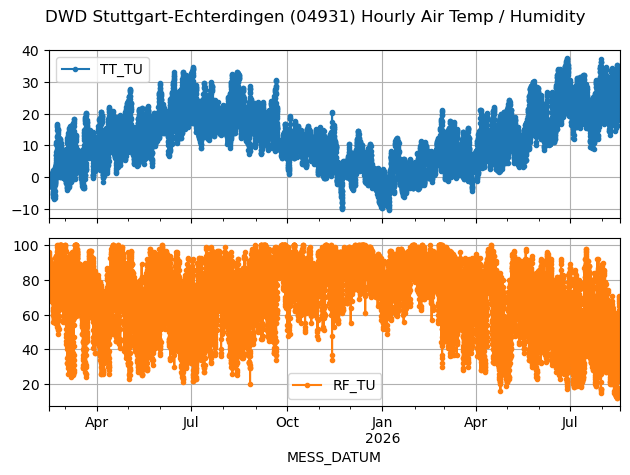

In [37]:
dwd_df = pd.read_csv(produkt_path, sep=';')
dwd_df.columns = dwd_df.columns.str.strip()

# MESS_DATUM is an hourly timestamp formatted as YYYYMMDDHH
dwd_df['MESS_DATUM'] = pd.to_datetime(dwd_df['MESS_DATUM'], format='%Y%m%d%H')
dwd_df = dwd_df.set_index('MESS_DATUM')

# DWD uses -999 as a missing-value marker
dwd_df.loc[dwd_df['TT_TU'] == -999, 'TT_TU'] = np.nan
dwd_df.loc[dwd_df['RF_TU'] == -999, 'RF_TU'] = np.nan

dwd_df[['TT_TU', 'RF_TU']].plot(
    subplots=True,
    grid=True,
    marker='.',
    title='DWD Stuttgart-Echterdingen (04931) Hourly Air Temp / Humidity'
)
plt.tight_layout()

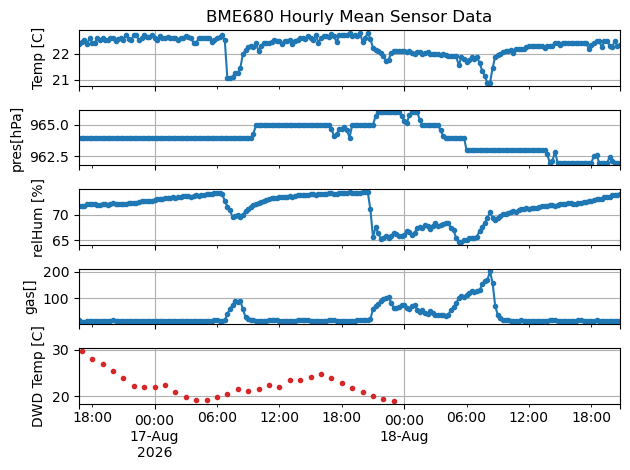

In [39]:
AVG = '15min'

fnames = [
    'sensor_data_2026-08-01_11_12_05.csv',
    'sensor_data_2026-08-01_12_49_16.csv',
    'sensor_data_2026-08-01_13_07_13.csv',
    'sensor_data_2026-08-09_14_57_20.csv',
    'sensor_data_2026-08-10_07_31_15.csv',
    'sensor_data_2026-08-12_16_50_41.csv',
    'sensor_data_2026-08-16_16_45_23.csv',
    'sensor_data_2026-08-17_08_17_41.csv'
]

dfs = {}

for fname in fnames:
    csv_path = Path(f'../data/{fname}').resolve()
    df = pd.read_csv(csv_path)
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.set_index('datetime')
    dfs[fname] = df

plot_df = pd.concat(
    [df.assign(source_file=fname) for fname, df in dfs.items()]
).sort_index()

# Filter to only include data starting from Aug-9
plot_df = plot_df[plot_df.index >= '2026-08-16']

# Filter pressure values below 100 hPa to NaN before averaging.
plot_df.loc[plot_df['pres[hPa]'] < 100, 'pres[hPa]'] = np.nan


plot_cols = ['Temp [C]', 'pres[hPa]', 'relHum [%]', 'gas[]']
hourly_df = plot_df[plot_cols].resample(AVG).mean()

fig, axes = plt.subplots(nrows=5, ncols=1, sharex=True)

for ax, col in zip(axes[:4], plot_cols):
    hourly_df[col].plot(ax=ax, grid=True, marker='.')
    ax.set_ylabel(col)

axes[0].set_title('BME680 Hourly Mean Sensor Data')

dwd_temp = dwd_df['TT_TU'].reindex(dwd_df.index.union(hourly_df.index)).sort_index()
dwd_temp = dwd_temp[(dwd_temp.index >= hourly_df.index.min()) & (dwd_temp.index <= hourly_df.index.max())]
dwd_temp.plot(ax=axes[4], grid=True, marker='.', color='tab:red')
axes[4].set_ylabel('DWD Temp [C]')
axes[4].set_xlim(hourly_df.index.min(), hourly_df.index.max())

plt.tight_layout()
#plt.show()
now = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
fname_fig = f'BME680_sensor_data_{AVG}_{now}.png'
fig_out = Path(f'../out/{fname_fig}')
plt.savefig(fig_out, dpi=300)